# Partie 1 - Statistique univariée

In [10]:
# Imports de base
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Optionnel : pour des graphiques un peu plus jolis si installé
try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except ImportError:
    sns = None

# Affichage plus lisible
pd.set_option("display.max_columns", None)

In [9]:
# Chargement du jeu de données bancaires : bank-additional-full.csv

bank_df = pd.read_csv("bank-additional-full.csv/bank-additional-full.csv", sep=";")
bank_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
# Aperçu rapide de la structure du jeu de données
bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

## Typologie des variables

### 1. Variables quantitatives
- `age`
- `campaign`
- `pdays`
- `previous`
- `emp.var.rate`
- `cons.price.idx`
- `cons.conf.idx`
- `euribor3m`
- `nr.employed`

### 2. Variables qualitatives

#### 2.1 Nominales
- `job`
- `marital`
- `contact`
- `poutcome`

#### 2.2 Ordinales
- `education`
- `month`
- `day_of_week`

### 3. Variables booléennes
- `default`
- `housing`
- `loan`
- `y`

---
**NB** : 

- `month`, `day_of_week` sont des variables ordinales circulaires
- Les données manquantes sont encodées en "unknown"


#  Analyse univariée des variables quantitatives 

###  Mesures de tendance centrale : Moyenne, Médiane, Mode


In [40]:
def calculate_central_tendency_stats(df, list_numerical_var) : 

    for var in list_numerical_var : 
        
        print(f"Mesures de tendance centrale pour la variable : {var}")

        mean_value = df[var].mean()
        median_value = df[var].median()
        mode_values = df[var].mode()  # peut retourner plusieurs valeurs
        
        print(f"Moyenne : {mean_value:.2f}")
        print(f"Médiane : {median_value:.2f}")
        print("Mode(s) :")
        print(f"{mode_values} \n")
        
    

In [42]:
numerical_variables = ["age", "campaign", "pdays", "previous", "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]
calculate_central_tendency_stats(bank_df, numerical_variables)

Mesures de tendance centrale pour la variable : age
Moyenne : 40.02
Médiane : 38.00
Mode(s) :
0    31
Name: age, dtype: int64 

Mesures de tendance centrale pour la variable : campaign
Moyenne : 2.57
Médiane : 2.00
Mode(s) :
0    1
Name: campaign, dtype: int64 

Mesures de tendance centrale pour la variable : pdays
Moyenne : 962.48
Médiane : 999.00
Mode(s) :
0    999
Name: pdays, dtype: int64 

Mesures de tendance centrale pour la variable : previous
Moyenne : 0.17
Médiane : 0.00
Mode(s) :
0    0
Name: previous, dtype: int64 

Mesures de tendance centrale pour la variable : emp.var.rate
Moyenne : 0.08
Médiane : 1.10
Mode(s) :
0    1.4
Name: emp.var.rate, dtype: float64 

Mesures de tendance centrale pour la variable : cons.price.idx
Moyenne : 93.58
Médiane : 93.75
Mode(s) :
0    93.994
Name: cons.price.idx, dtype: float64 

Mesures de tendance centrale pour la variable : cons.conf.idx
Moyenne : -40.50
Médiane : -41.80
Mode(s) :
0   -36.4
Name: cons.conf.idx, dtype: float64 

Mesures de

### Interprétation : une observation réprésente un contact client

- **La variable** `age`

La moyenne (40.02) est légèrement supérieure à la médiane (38.00), ce qui suggère une asymétrie positive modérée de la distribution des âges. 

Cela indique la présence de quelques individus plus âgés qui tirent la moyenne vers le haut.

La médiane étant de 38 ans, cela signifie que 50 % de la population a un âge inférieur ou égal à 38 ans, et 50 % un âge supérieur.

La population semble donc relativement jeune, bien que la présence de valeurs plus élevées crée une légère asymétrie à droite.

- **La variable** `campaign`

La moyenne (2.57) est supérieure à la médiane (2.00), ce qui suggère une légère asymétrie positive de la distribution.

Cela indique que si la majorité des clients ont été contactés une ou deux fois (mode = 1), certains clients ont nécessité un nombre plus élevé de contacts, ce qui tire la moyenne vers le haut.

La médiane étant de 2, on peut considérer que le nombre typique de contacts par client est de deux.

- **La variable** `pdays`

Les mesures de tendance centrale de la variable pdays sont fortement biaisées, car plus de 80% des clients n'ont jamais été contactés lors d'une campagne précédente.

Cette situation est encodée par la valeur 999, qui ne représente pas un nombre réel de jours écoulés, mais une absence de contact antérieur.

Ainsi, la variable mélange une information binaire (avoir été contacté ou non) et une information quantitative (nombre de jours depuis le dernier contact, variant entre 0 et 27 jours).

Cette structure rend les indicateurs statistiques classiques (moyenne, médiane) peu représentatifs et nécessite une transformation de la variable pour une exploitation pertinente (feature engineering).

- **La variable** `previous`

La variable previous présente une distribution fortement asymétrique à droite, caractérisée par une concentration massive de valeurs nulles (35 563 observations).

La moyenne (0,17) étant supérieure à la médiane (0), cela confirme la présence d’une queue positive constituée d’un faible nombre de clients ayant été contactés plusieurs fois auparavant.

Cette distribution suggère que la majorité des clients n’avaient fait l’objet d’aucun contact lors des campagnes précédentes.

On peut ainsi formuler l’hypothèse que la campagne actuelle cible principalement des clients n’ayant pas été sollicités auparavant dans le cadre de campagnes marketing similaires.

- **La variable** `cons.price.idx`

Les mesures de tendance centrale de la variable cons.price.idx sont relativement proches (moyenne = 93.58, médiane = 93.75, mode = 93.994), ce qui suggère une distribution globalement peu asymétrique

Toutefois, cette variable étant un indicateur macroéconomique mensuel, sa distribution reflète principalement la fréquence des mois présents dans le dataset plutôt qu’une dispersion individuelle. Il convient donc d’interpréter cette variable comme un facteur contextuel temporel plutôt qu’une caractéristique propre aux clients (cons.price.idx = valeur du CPI du mois où on l’a contacté).

- **La variable** `emp.var.rate`

La moyenne (0.08) est inférieure à la médiane (1.10), ce qui suggère une asymétrie négative de la distribution.

Cette différence indique la présence de valeurs plus faibles, voire négatives, qui tirent la moyenne vers le bas.

Étant donné que cette variable représente la variation trimestrielle du taux d’emploi, ces valeurs négatives peuvent correspondre à des périodes de ralentissement économique.

- **La variable** `cons.conf.idx`
  
La moyenne (-40.50) est légèrement supérieure à la médiane (-41.80), ce qui suggère une asymétrie positive de la distribution.

Cette différence indique la présence de valeurs relativement plus élevées (moins négatives), qui tirent la moyenne vers le haut.

Étant donné que cette variable représente un indice mensuel de confiance des consommateurs, ces variations reflètent différentes périodes de conjoncture économique plus ou moins favorable.

- **La variable** `euribor3m`

La moyenne (3.62) est inférieure à la médiane (4.86), ce qui suggère une asymétrie négative de la distribution.

Cette différence indique la présence de valeurs plus faibles du taux Euribor, qui tirent la moyenne vers le bas.

Cette configuration peut s’expliquer par la baisse marquée des taux d’intérêt observée lors de périodes de ralentissement économique, notamment après la crise financière.

- **La variable** `nr.employed`

La moyenne (5167.04) est légèrement inférieure à la médiane (5191.00), ce qui suggère une légère asymétrie négative de la distribution.

Cette différence indique la présence de périodes où le nombre d’employés était plus faible, ce qui abaisse modérément la moyenne.

Toutefois, l’écart entre les indicateurs de tendance centrale reste faible, ce qui suggère une relative stabilité du niveau d’emploi sur la période étudiée.

###  Mesures de dispersion : Variance, Écart-type, Étendue, Coefficient de variation


In [43]:
def calculate_dispersion_tendency_stats(df, list_numerical_var) : 

    for var in list_numerical_var : 
        
        print(f"Mesures de dispersion pour la variable : {var}")

        variance = df[var].var(ddof=1)          # variance empirique
        std_dev = df[var].std(ddof=1)           # écart-type
        vmin = df[var].min()
        vmax = df[var].max()
        etendue = vmax - vmin
        cv = (std_dev / df[var].mean()) * 100
        
        print(f"Variance : {variance:.2f}")
        print(f"Écart-type : {std_dev:.2f}")
        print(f"Min : {vmin:.2f}")
        print(f"Max : {vmax:.2f}")
        print(f"Étendue : {etendue:.2f}")
        print(f"Coefficient de variation : {cv:.2f} %\n")

In [19]:
categorical_columns = bank_df.select_dtypes(include=["object"]).columns
for col in categorical_columns :
    print(f"{bank_df[col].value_counts()}\n\n")

job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64


marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64


education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64


default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64


housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64


loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64


contact
cellular     26144
telephone    15044
Name: coun

In [44]:
calculate_dispersion_tendency_stats(bank_df, numerical_variables)

Mesures de dispersion pour la variable : age
Variance : 108.60
Écart-type : 10.42
Min : 17.00
Max : 98.00
Étendue : 81.00
Coefficient de variation : 26.04 %

Mesures de dispersion pour la variable : campaign
Variance : 7.67
Écart-type : 2.77
Min : 1.00
Max : 56.00
Étendue : 55.00
Coefficient de variation : 107.88 %

Mesures de dispersion pour la variable : pdays
Variance : 34935.69
Écart-type : 186.91
Min : 0.00
Max : 999.00
Étendue : 999.00
Coefficient de variation : 19.42 %

Mesures de dispersion pour la variable : previous
Variance : 0.24
Écart-type : 0.49
Min : 0.00
Max : 7.00
Étendue : 7.00
Coefficient de variation : 286.13 %

Mesures de dispersion pour la variable : emp.var.rate
Variance : 2.47
Écart-type : 1.57
Min : -3.40
Max : 1.40
Étendue : 4.80
Coefficient de variation : 1918.48 %

Mesures de dispersion pour la variable : cons.price.idx
Variance : 0.34
Écart-type : 0.58
Min : 92.20
Max : 94.77
Étendue : 2.57
Coefficient de variation : 0.62 %

Mesures de dispersion pour la va

### Interprétation :

- **La variable** `age`

L’âge des clients présente un écart-type de 10,42 ans, indiquant une dispersion modérée autour de la moyenne (≈ 40 ans).

Le coefficient de variation de 26% confirme une variabilité relative modérée au sein de la population étudiée.

Bien que l’étendue soit importante (81 ans), celle-ci est principalement influencée par la présence de quelques valeurs extrêmes (clients très jeunes ou très âgés).

Globalement, la population semble majoritairement composée d’adultes d’âge moyen, avec une hétérogénéité raisonnable.

- **La variable** `campaign`

Le nombre de contacts effectués par client présente un écart-type (2.77) supérieur à la moyenne (2.57), ce qui traduit une forte dispersion relative.

Le coefficient de variation élevé (107.88%) confirme une variabilité importante du nombre de contacts entre les clients.

Bien que la majorité des clients aient été contactés un faible nombre de fois, la présence de quelques clients ayant nécessité un nombre très élevé d’appels (jusqu’à 56) génère une asymétrie marquée à droite et augmente significativement la dispersion globale.

-  **La variable** `pdays`

Les mesures de dispersion de la variable pdays sont fortement influencées par la valeur 999, qui ne représente pas un délai réel mais un code indiquant l’absence de contact précédent.

Par conséquent, la variance, l’écart-type et l’étendue reflètent principalement la structure de codage de la variable plutôt qu’une dispersion réelle des délais observés.

Une transformation de la variable est donc nécessaire afin de séparer l’information binaire (contact antérieur ou non) de l’information quantitative (nombre de jours écoulés).

- **La variable** `previous`
  
La variable previous présente un écart-type (0.49) supérieur à la moyenne (≈0.17), traduisant une forte dispersion relative.

Le coefficient de variation très élevé (286%) confirme une hétérogénéité importante, bien que celle-ci soit accentuée par la faible valeur moyenne de la variable.

La distribution est fortement asymétrique à droite, caractérisée par une concentration massive de zéros et une queue positive correspondant à quelques clients ayant fait l’objet de plusieurs contacts antérieurs.

Cette structure reflète le fait que la majorité des clients n’avaient pas été sollicités avant cette campagne.

- **Les variables** `cons.price.idx`, `emp.var.rate`, `cons.conf.idx`, `euribor3m`, `nr.employed`

L’analyse des mesures de dispersion des variables macroéconomiques révèle une relative stabilité globale de l’environnement économique sur la période étudiée.

Les indices de prix à la consommation et le nombre d’employés présentent une très faible variabilité relative, traduisant une certaine constance structurelle.

En revanche, le taux Euribor à 3 mois affiche une variabilité plus marquée, reflétant les fluctuations significatives des taux d’intérêt durant la période.

Le coefficient de variation extrêmement élevé de la variable emp.var.rate s’explique par une moyenne proche de zéro et ne doit pas être interprété comme une forte instabilité réelle.

###  Mesures de position : quartiles, quantiles, IQR et bornes d’outliers

In [45]:
def calculate_position_tendency_stats(df, list_numerical_var) : 

    for var in list_numerical_var : 

        print(f"Mesures de position pour la variable : {var}")
        
        q1 = df[var].quantile(0.25)
        q2 = df[var].quantile(0.50)
        q3 = df[var].quantile(0.75)
        iqr = q3 - q1
        
        borne_inf = q1 - 1.5 * iqr
        borne_sup = q3 + 1.5 * iqr
        
        print(f"Q1 : {q1:.2f}")
        print(f"Q2 (médiane) : {q2:.2f}")
        print(f"Q3 : {q3:.2f}")
        print(f"IQR : {iqr:.2f}")
        print(f"Borne inférieure (outliers) : {borne_inf:.2f}")
        print(f"Borne supérieure (outliers) : {borne_sup:.2f}")
        
        outliers = df[(df[var] < borne_inf) | (df[var] > borne_sup)]
        print(f"\nNombre d'outliers détectés : {outliers.shape[0]}\n")

In [46]:
calculate_position_tendency_stats(bank_df, numerical_variables)

Mesures de position pour la variable : age
Q1 : 32.00
Q2 (médiane) : 38.00
Q3 : 47.00
IQR : 15.00
Borne inférieure (outliers) : 9.50
Borne supérieure (outliers) : 69.50

Nombre d'outliers détectés : 469

Mesures de position pour la variable : campaign
Q1 : 1.00
Q2 (médiane) : 2.00
Q3 : 3.00
IQR : 2.00
Borne inférieure (outliers) : -2.00
Borne supérieure (outliers) : 6.00

Nombre d'outliers détectés : 2406

Mesures de position pour la variable : pdays
Q1 : 999.00
Q2 (médiane) : 999.00
Q3 : 999.00
IQR : 0.00
Borne inférieure (outliers) : 999.00
Borne supérieure (outliers) : 999.00

Nombre d'outliers détectés : 1515

Mesures de position pour la variable : previous
Q1 : 0.00
Q2 (médiane) : 0.00
Q3 : 0.00
IQR : 0.00
Borne inférieure (outliers) : 0.00
Borne supérieure (outliers) : 0.00

Nombre d'outliers détectés : 5625

Mesures de position pour la variable : emp.var.rate
Q1 : -1.80
Q2 (médiane) : 1.10
Q3 : 1.40
IQR : 3.20
Borne inférieure (outliers) : -6.60
Borne supérieure (outliers) : 6.2

### Interprétation :

- **La variable** `age`

Les quartiles indiquent que la moitié des clients ont un âge compris entre 32 et 47 ans, avec une médiane de 38 ans.

L’intervalle interquartile (15 ans) traduit une dispersion modérée de l’âge autour de la médiane.

Les bornes d’outliers suggèrent la présence de quelques clients très âgés (plus de 69,5 ans), bien que ces observations restent plausibles dans le contexte bancaire.

- **La variable** `campaign`

Les quartiles indiquent que 75% des clients ont été contactés au plus trois fois durant la campagne, avec une médiane de deux contacts.

L’intervalle interquartile (2) montre que les 50% centraux des observations se situent entre 1 et 3 contacts, traduisant une concentration importante des données autour de faibles nombres d’appels.

Les bornes d’outliers (supérieure à 6 contacts) révèlent la présence de clients ayant nécessité un nombre d’appels nettement plus élevé que la majorité. Ces observations contribuent à une asymétrie marquée à droite de la distribution et reflètent l’hétérogénéité des efforts marketing nécessaires pour convaincre certains clients

- **La variable** `pdays`
  
Les mesures de position de la variable pdays ne sont pas directement interprétables. En effet, la valeur 999 correspond à un code indiquant qu’aucun contact antérieur n’a eu lieu, et non à un nombre réel de jours. Comme cette valeur représente la grande majorité des observations, les quartiles et l’intervalle interquartile sont entièrement déterminés par ce code, ce qui rend l’analyse descriptive biaisée. Il est donc nécessaire de transformer cette variable afin de distinguer les clients précédemment contactés de ceux qui ne l’ont jamais été.

- **La variable** `previous`
  
Les quartiles de la variable previous sont tous égaux à zéro, ce qui indique qu’au moins 75 % des clients n’avaient fait l’objet d’aucun contact lors de campagnes précédentes. Cette concentration massive de zéros entraîne un intervalle interquartile nul, rendant la détection d’outliers par la méthode IQR non pertinente. Les valeurs positives observées correspondent simplement à une minorité de clients ayant déjà été contactés auparavant et traduisent une asymétrie marquée à droite de la distribution.

**NB** :
Les variables macroéconomiques décrivent le contexte économique au moment du contact et ne sont pas spécifiques aux clients. Par conséquent, leurs mesures de position reflètent principalement la fréquence des périodes observées dans le dataset plutôt qu’une véritable distribution individuelle. Leur analyse descriptive reste donc limitée et leur intérêt réside davantage dans l’étude de leur relation avec la variable cible.


### Forme de la distribution : asymétrie et aplatissement (skewness, kurtosis)  

In [50]:
def calculate_skewness_kurtosis(df, list_numerical_var) :

    for var in list_numerical_var :

        print(f"Mesures d'asymétrie et d'aplatissement pour la variable : {var}")
        
        skewness = df[var].skew()
        kurtosis = df[var].kurtosis()  # kurtosis "excess" (0 si normale théorique)
        
        print(f"Skewness (asymétrie) : {skewness:.3f}")
        print(f"Kurtosis (aplatissement) : {kurtosis:.3f}\n")

In [51]:
calculate_skewness_kurtosis(bank_df, numerical_variables)

Mesures d'asymétrie et d'aplatissement pour la variable : age
Skewness (asymétrie) : 0.785
Kurtosis (aplatissement) : 0.791

Mesures d'asymétrie et d'aplatissement pour la variable : campaign
Skewness (asymétrie) : 4.763
Kurtosis (aplatissement) : 36.980

Mesures d'asymétrie et d'aplatissement pour la variable : pdays
Skewness (asymétrie) : -4.922
Kurtosis (aplatissement) : 22.229

Mesures d'asymétrie et d'aplatissement pour la variable : previous
Skewness (asymétrie) : 3.832
Kurtosis (aplatissement) : 20.109

Mesures d'asymétrie et d'aplatissement pour la variable : emp.var.rate
Skewness (asymétrie) : -0.724
Kurtosis (aplatissement) : -1.063

Mesures d'asymétrie et d'aplatissement pour la variable : cons.price.idx
Skewness (asymétrie) : -0.231
Kurtosis (aplatissement) : -0.830

Mesures d'asymétrie et d'aplatissement pour la variable : cons.conf.idx
Skewness (asymétrie) : 0.303
Kurtosis (aplatissement) : -0.359

Mesures d'asymétrie et d'aplatissement pour la variable : euribor3m
Skewne

### Visualisations (histogramme, KDE, boxplot)

- Histogrammes

In [63]:
def plot_histogramms(df, list_numerical_var) :

    rows = 3
    cols = 3
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, var in enumerate(list_numerical_var):
        if i < rows * cols:
            axes[i].hist(df[var], bins="auto")
            axes[i].set_title(var)
    
    # Supprimer les subplots inutilisés
    for j in range(i + 1, rows * cols):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

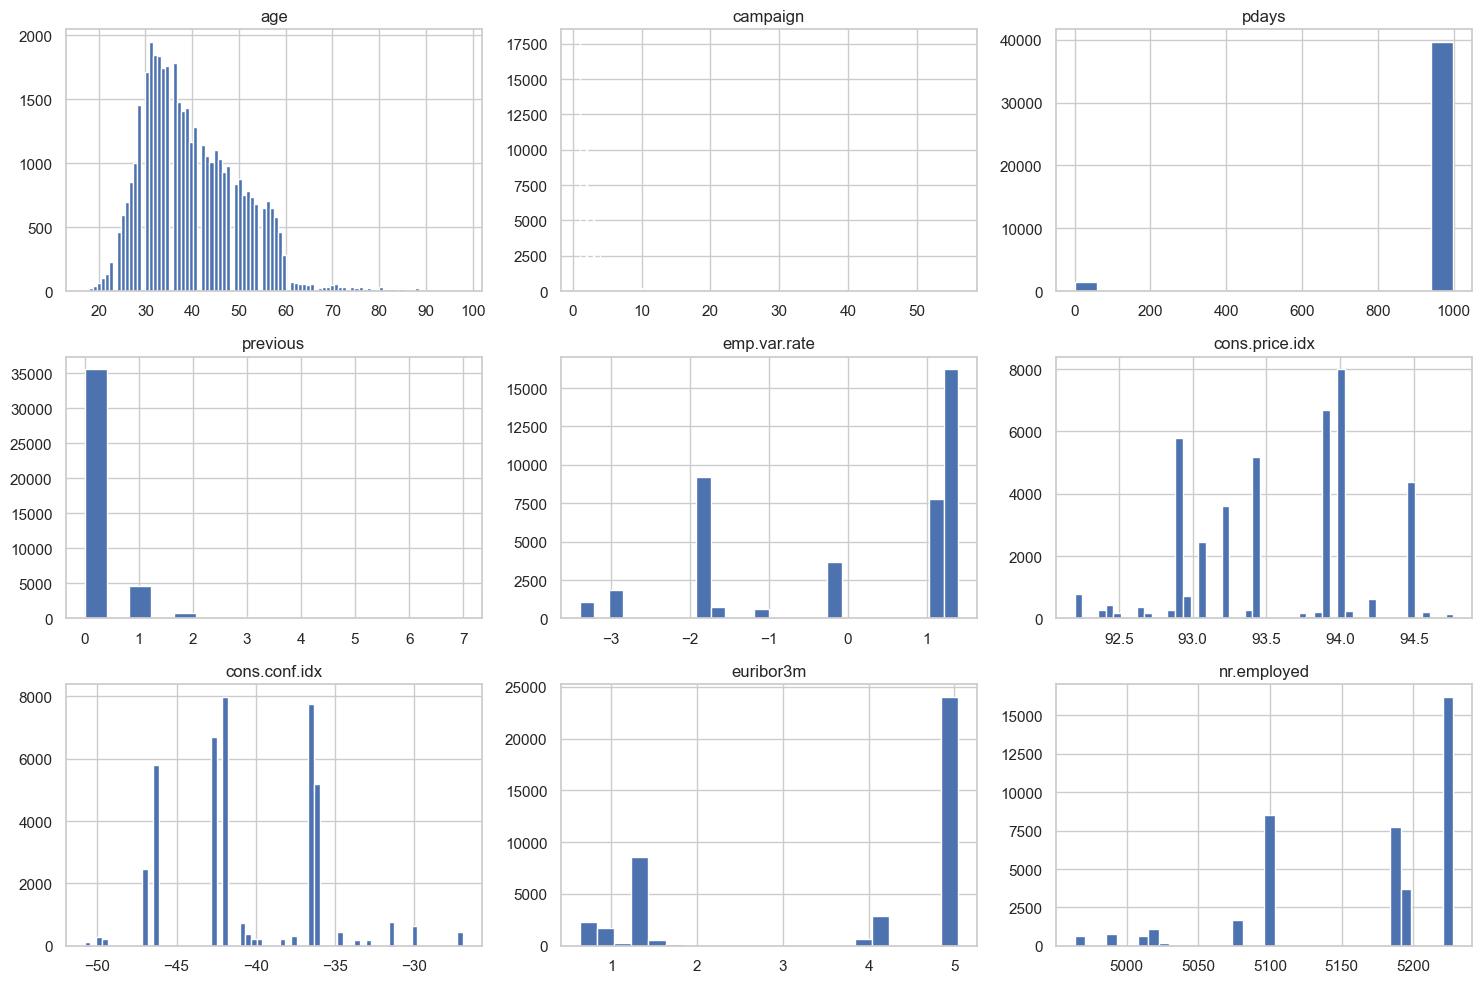

In [64]:
plot_histogramms(bank_df, numerical_variables)

- KDE

In [66]:
def plot_kde(df, list_numerical_var) :

    rows = 3
    cols = 3
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, var in enumerate(list_numerical_var):
        if i < rows * cols:
            sns.kdeplot(df[var], ax=axes[i], fill=True)
            axes[i].set_title(var)
    
    # Supprimer les subplots inutilisés
    for j in range(i + 1, rows * cols):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

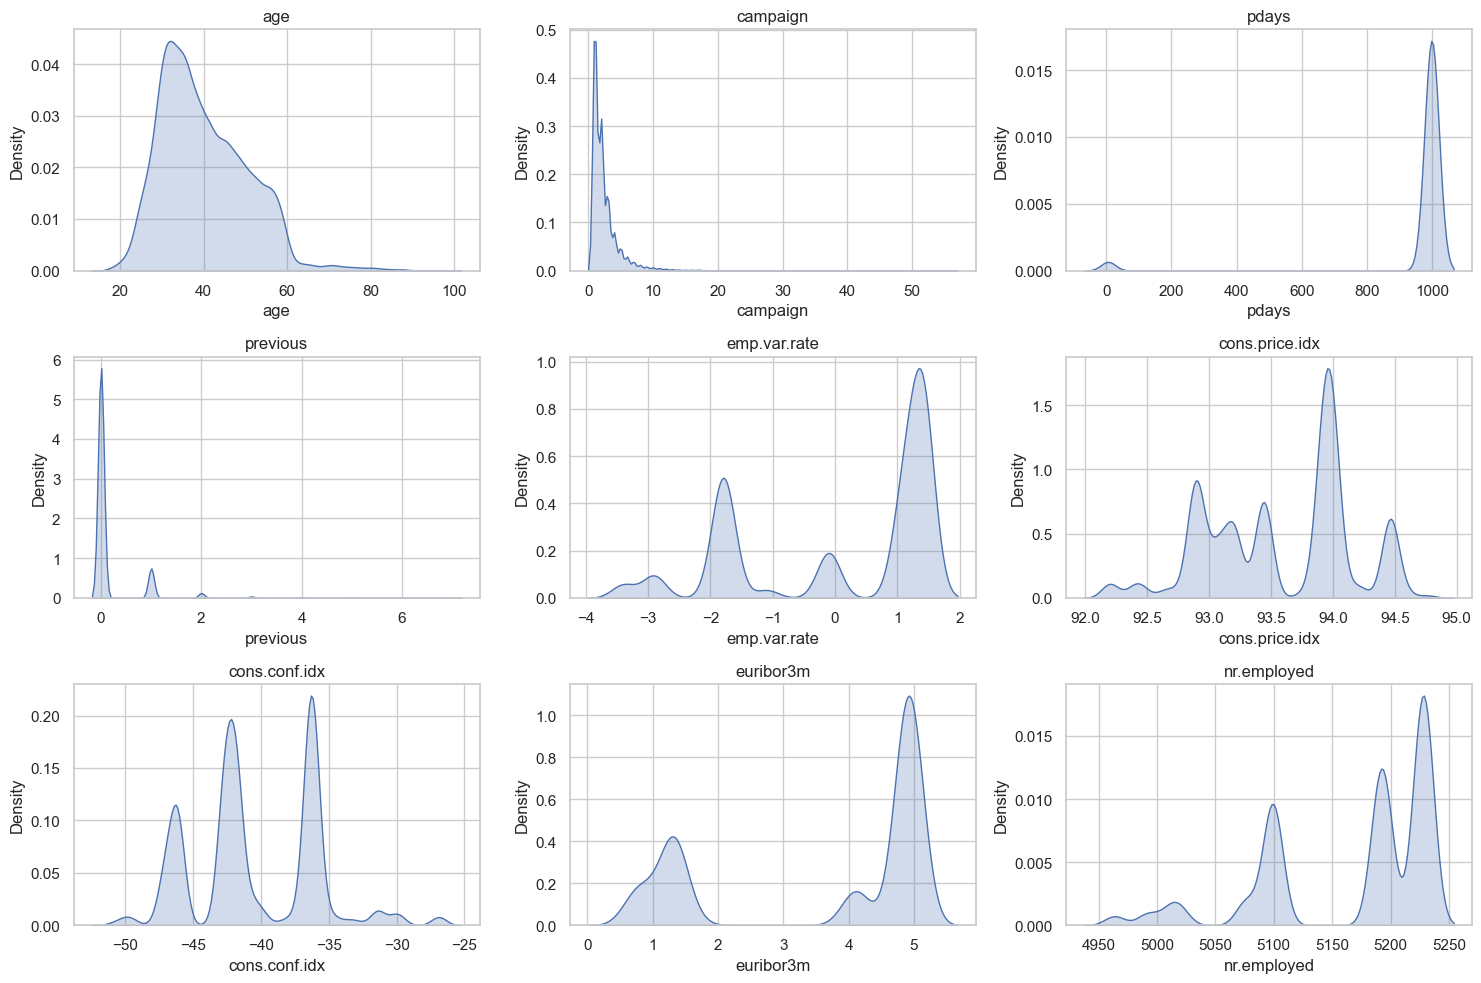

In [67]:
plot_kde(bank_df, numerical_variables)

- Boxplots

In [68]:
def plot_boxplots(df, list_numerical_var) :

    rows = 3
    cols = 3
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, var in enumerate(list_numerical_var):
        if i < rows * cols:
            sns.boxplot(df[var], ax=axes[i], color="#4C72B0")
            axes[i].set_title(var)
    
    # Supprimer les subplots inutilisés
    for j in range(i + 1, rows * cols):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

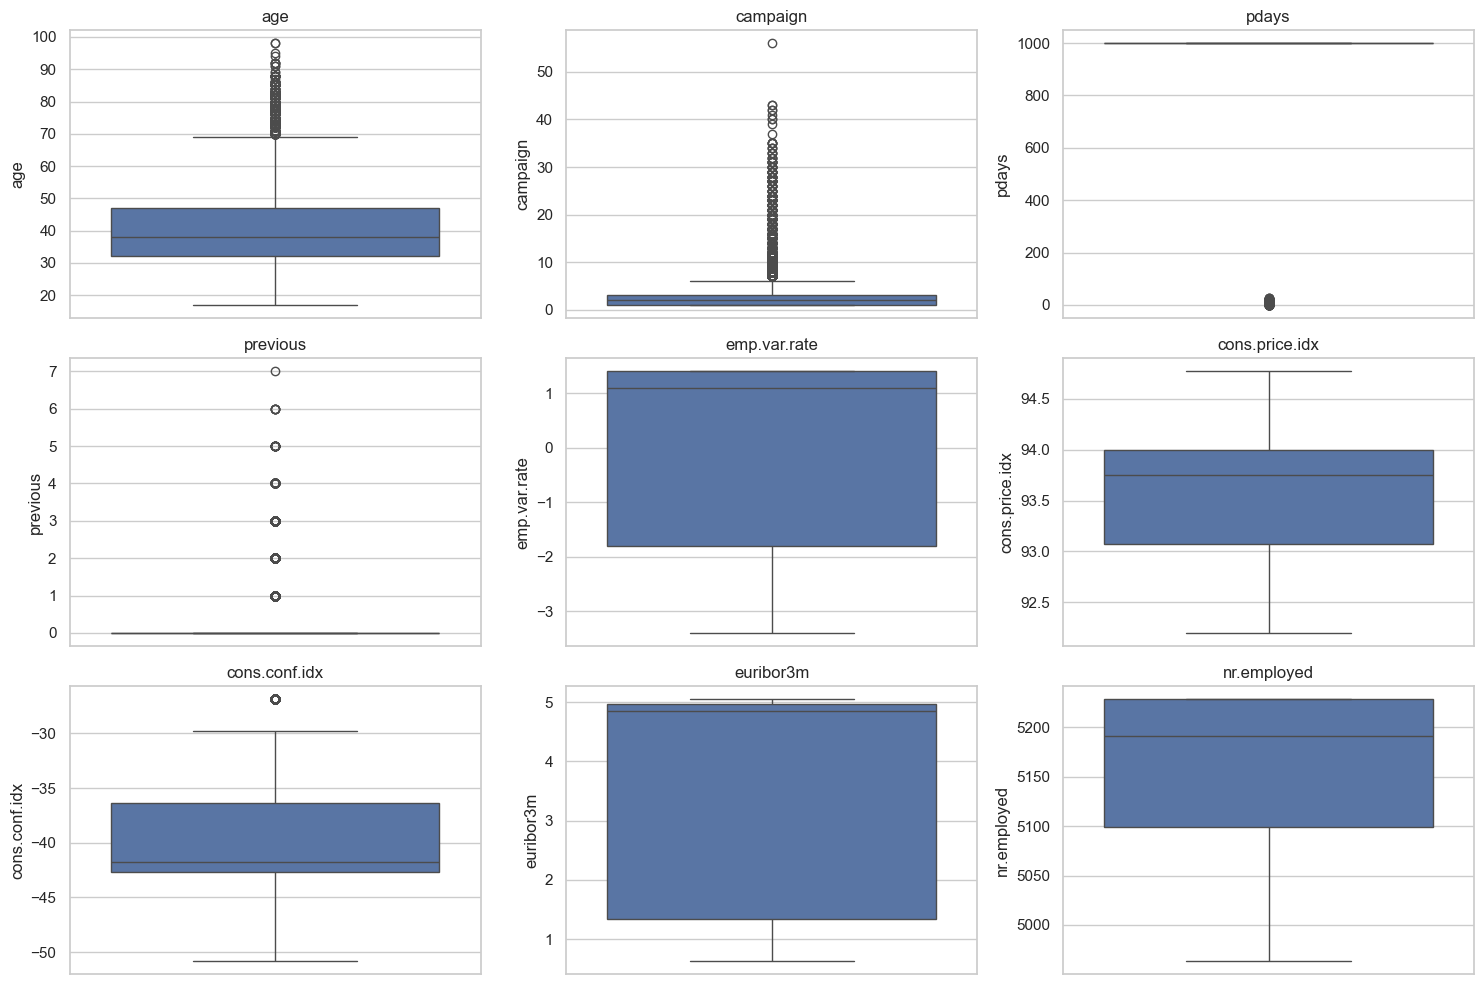

In [69]:
plot_boxplots(bank_df, numerical_variables)

### Interprétation des boxplots
- Pour les variables macroéconomiques, la position de la médiane dans les boxplots suggère une asymétrie à gauche de la distribution. Cette asymétrie reflète principalement la présence de certaines périodes économiques moins favorables dans les données. Toutefois, ces variables étant liées au contexte macroéconomique au moment du contact, leur distribution dépend essentiellement des périodes couvertes par la campagne.

- L’absence de boîte dans certains boxplots (notamment pdays et previous) indique que l’intervalle interquartile est nul, ce qui signifie que les 50 % centraux des observations prennent la même valeur. Cette situation reflète une forte concentration des données sur une valeur unique et traduit une distribution très asymétrique, caractérisée par une majorité d'observations identiques et une minorité de valeurs différentes.

- Les nombreux outliers détectés correspondent principalement à des observations rares mais plausibles dans le contexte d’une campagne marketing. Ils traduisent des comportements atypiques plutôt que des erreurs de données, et ne doivent donc pas être considérés comme des valeurs aberrantes. 

#  Analyse univariée des variables quanlitatives

In [71]:
categorical_variables = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "day_of_week", "poutcome"]


###  Effectifs et proportions


In [78]:
def compute_headcounts(df, categorical_variables) :
    
    for var in categorical_variables : 

        print(f"Effectifs pour la variable : {var} \n")
        effectifs = df[var].value_counts()
        print(f"{effectifs}\n")

In [79]:
compute_headcounts(bank_df, categorical_variables)

Effectifs pour la variable : job 

job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

Effectifs pour la variable : marital 

marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

Effectifs pour la variable : education 

education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

Effectifs pour la variable : default 

default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

Effectifs pour la variable : housing 

housing
yes        21576
no         18

In [105]:
def compute_proportions(df, categorical_variables) :
    
    for var in categorical_variables : 

        print(f"Effectifs pour la variable : {var} \n")
        proportions = df[var].value_counts(normalize=True) * 100
        print(f"{proportions.round(2)}\n")

In [106]:
compute_proportions(bank_df, categorical_variables)

Effectifs pour la variable : job 

job
admin.           25.30
blue-collar      22.47
technician       16.37
services          9.64
management        7.10
retired           4.18
entrepreneur      3.54
self-employed     3.45
housemaid         2.57
unemployed        2.46
student           2.12
unknown           0.80
Name: proportion, dtype: float64

Effectifs pour la variable : marital 

marital
married     60.52
single      28.09
divorced    11.20
unknown      0.19
Name: proportion, dtype: float64

Effectifs pour la variable : education 

education
university.degree      29.54
high.school            23.10
basic.9y               14.68
professional.course    12.73
basic.4y               10.14
basic.6y                5.56
unknown                 4.20
illiterate              0.04
Name: proportion, dtype: float64

Effectifs pour la variable : default 

default
no         79.12
unknown    20.87
yes         0.01
Name: proportion, dtype: float64

Effectifs pour la variable : housing 

housing
ye

NB : On observe que la modalité unknown apparaît dans plusieurs variables catégorielles avec des proportions différentes. Cela suggère qu’il ne s’agit pas de valeurs manquantes au sens classique, mais plutôt d’une catégorie indiquant que l’information n’est pas connue ou n’a pas été renseignée. Étant donné la proportion relativement importante de ces observations, il est préférable de conserver unknown comme une modalité à part entière plutôt que de la traiter comme une valeur manquante.

###  Graphiques : barplot, pie chart

In [83]:
def plot_bar_plots(df, categorical_variables) :

    for var in categorical_variables :

        plt.figure()
        ax = df[var].value_counts().plot(kind="bar")
        ax.bar_label(ax.containers[0]) 
        plt.title(f"Effectifs par modalité de {var}")
        plt.xlabel(var)
        plt.ylabel("Effectif")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
        

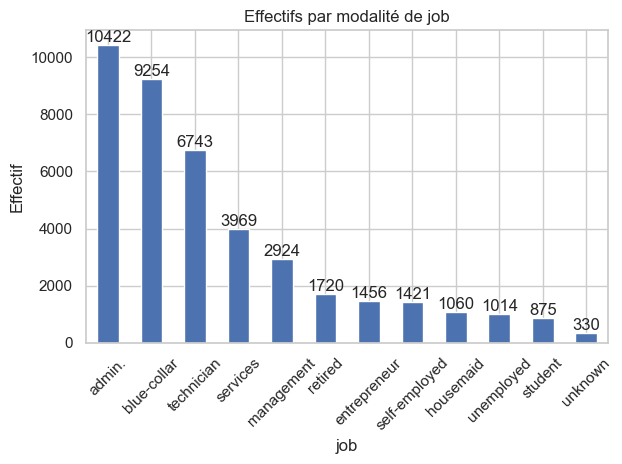

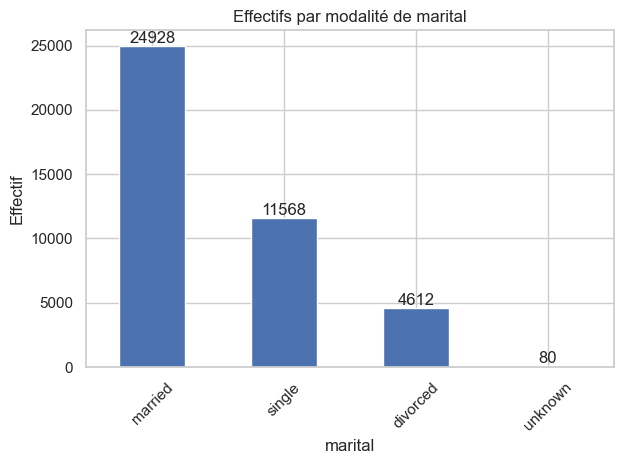

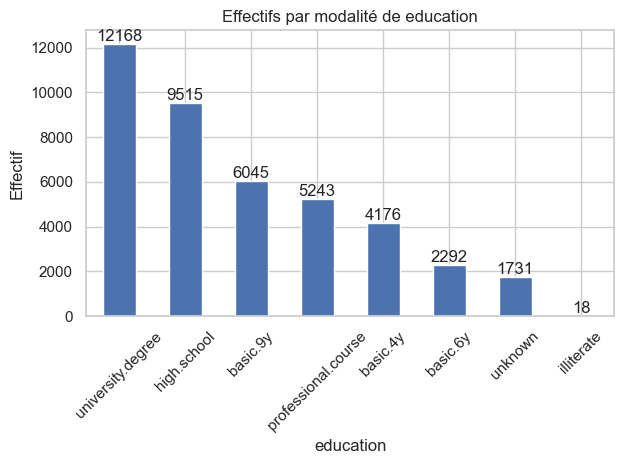

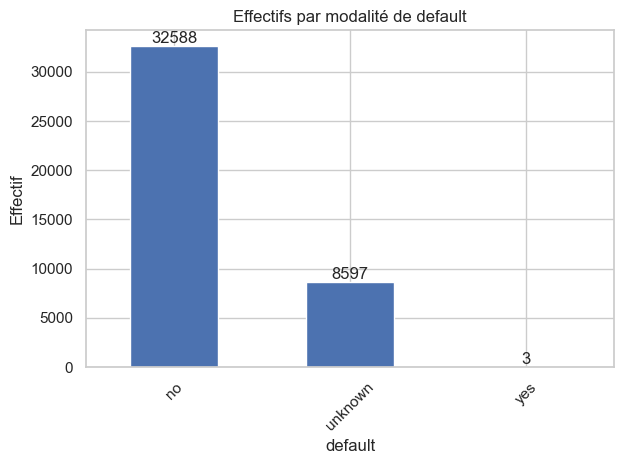

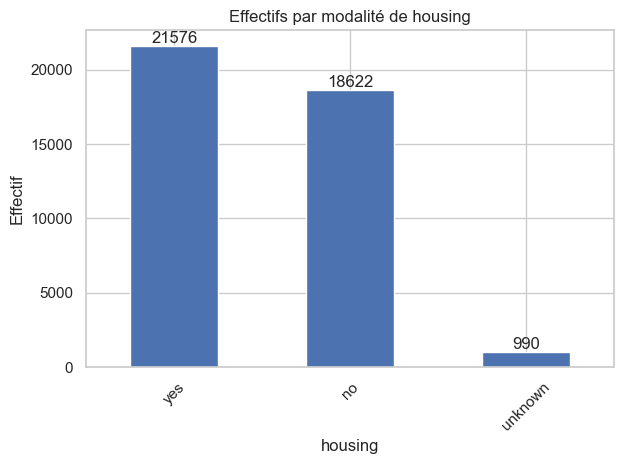

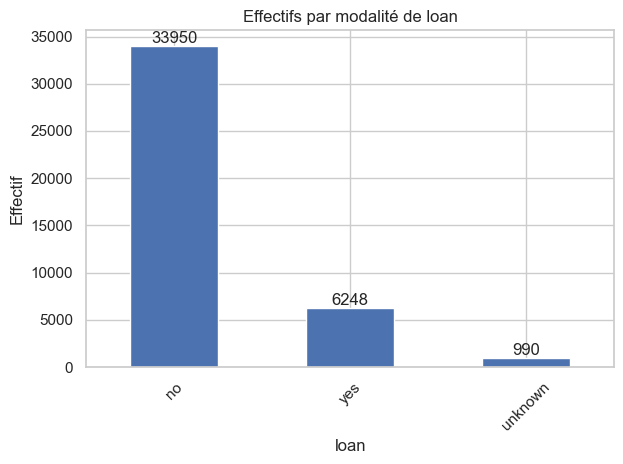

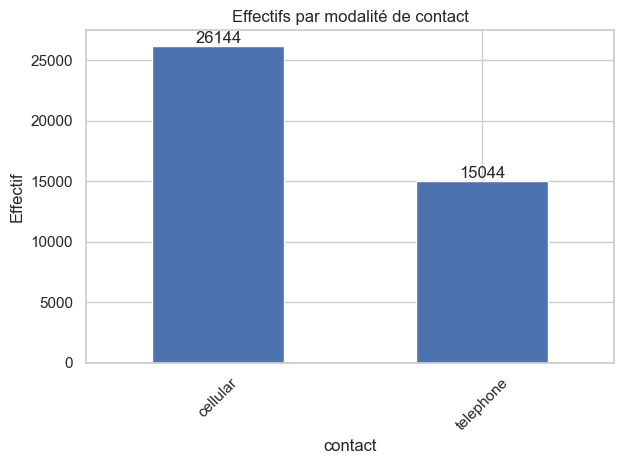

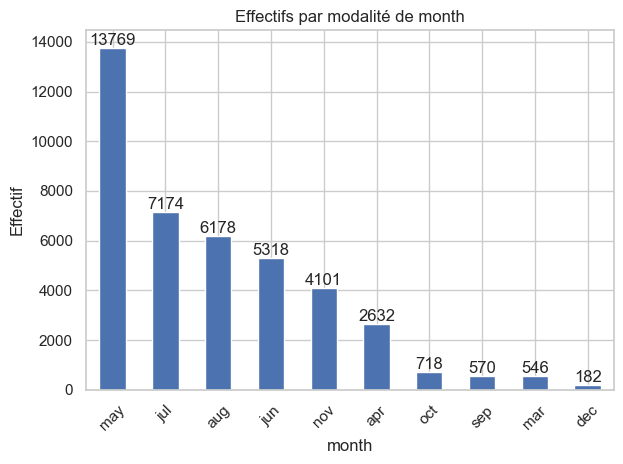

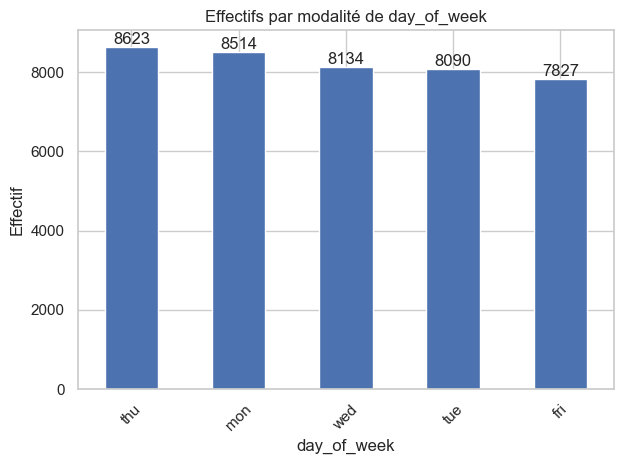

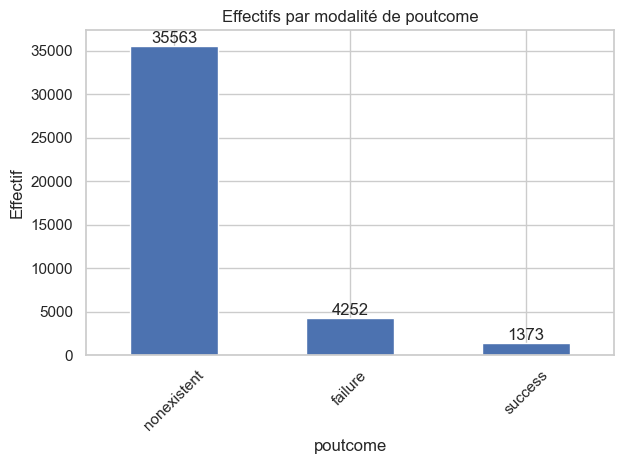

In [84]:
plot_bar_plots(bank_df, categorical_variables)

##  Tests de normalité


###  Test de Shapiro–Wilk

- **Hypothèse nulle H0** : la variable suit une loi normale ;
- **Hypothèse alternative H1** : la variable ne suit pas une loi normale.

On regarde la **p-valeur** :
- si p-valeur < 0,05 → on **rejette H0** → la variable n'est **pas normale** (au seuil de 5%) ;
- si p-valeur ≥ 0,05 → on **ne rejette pas H0** → la normalité est **plausible**.

In [87]:
def test_shapiro_wilk(df, list_numerical_var) :

    for var in list_numerical_var : 

        print(f"variable: {var} \n")
        shapiro_stat, shapiro_p = stats.shapiro(df[var].sample(min(len(df[var]), 500), random_state=42))
        print(f"Statistique de Shapiro–Wilk : {shapiro_stat:.4f}")
        print(f"p-valeur : {shapiro_p:.4f} \n")
    

In [89]:
test_shapiro_wilk(bank_df, numerical_variables)

variable: age 

Statistique de Shapiro–Wilk : 0.9562
p-valeur : 0.0000 

variable: campaign 

Statistique de Shapiro–Wilk : 0.4790
p-valeur : 0.0000 

variable: pdays 

Statistique de Shapiro–Wilk : 0.2122
p-valeur : 0.0000 

variable: previous 

Statistique de Shapiro–Wilk : 0.3881
p-valeur : 0.0000 

variable: emp.var.rate 

Statistique de Shapiro–Wilk : 0.7664
p-valeur : 0.0000 

variable: cons.price.idx 

Statistique de Shapiro–Wilk : 0.9380
p-valeur : 0.0000 

variable: cons.conf.idx 

Statistique de Shapiro–Wilk : 0.9222
p-valeur : 0.0000 

variable: euribor3m 

Statistique de Shapiro–Wilk : 0.6820
p-valeur : 0.0000 

variable: nr.employed 

Statistique de Shapiro–Wilk : 0.7705
p-valeur : 0.0000 



### Test de Kolmogorov–Smirnov (KS)

In [93]:
def Kolmogorov_Smirnov(df, list_numerical_var) :

    for var in list_numerical_var : 

        print(f"variable: {var} \n")
        var_std = (df[var] - df[var].mean()) / df[var].std(ddof=1)
        
        ks_stat, ks_p = stats.kstest(var_std, "norm")
        print(f"Statistique de KS : {ks_stat:.4f}")
        print(f"p-valeur : {ks_p:.4f}\n")

In [94]:
Kolmogorov_Smirnov(bank_df, numerical_variables)

variable: age 

Statistique de KS : 0.0944
p-valeur : 0.0000

variable: campaign 

Statistique de KS : 0.2857
p-valeur : 0.0000

variable: pdays 

Statistique de KS : 0.5407
p-valeur : 0.0000

variable: previous 

Statistique de KS : 0.5001
p-valeur : 0.0000

variable: emp.var.rate 

Statistique de KS : 0.3242
p-valeur : 0.0000

variable: cons.price.idx 

Statistique de KS : 0.2140
p-valeur : 0.0000

variable: cons.conf.idx 

Statistique de KS : 0.1903
p-valeur : 0.0000

variable: euribor3m 

Statistique de KS : 0.3455
p-valeur : 0.0000

variable: nr.employed 

Statistique de KS : 0.3020
p-valeur : 0.0000



###  Q-Q plot (Quantile-Quantile plot)

In [97]:
def Q_Q_plot(df, list_numerical_var) :

    for var in list_numerical_var :
        plt.figure()
        stats.probplot(df[var], dist="norm", plot=plt)
        plt.title(f"Q-Q plot pour {variable}")
        plt.show()
    

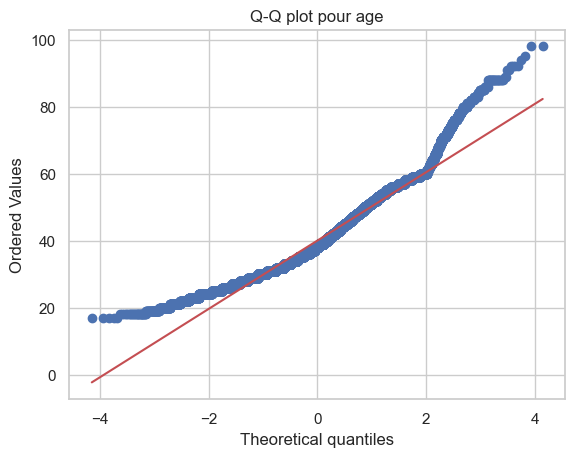

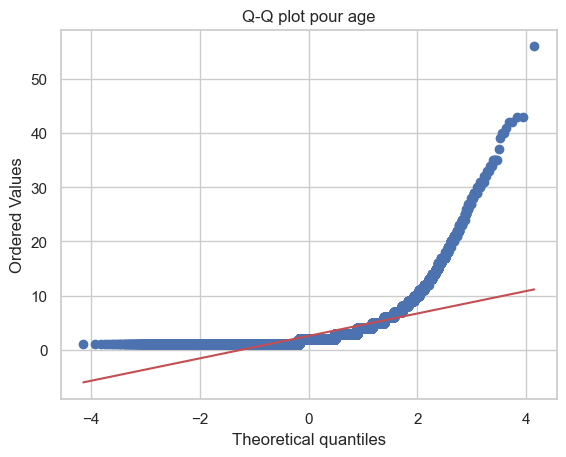

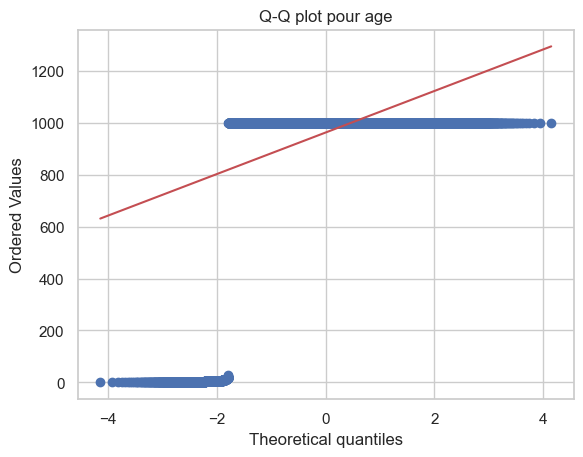

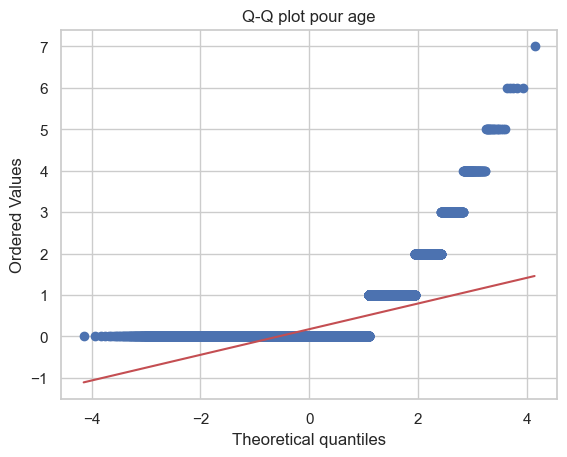

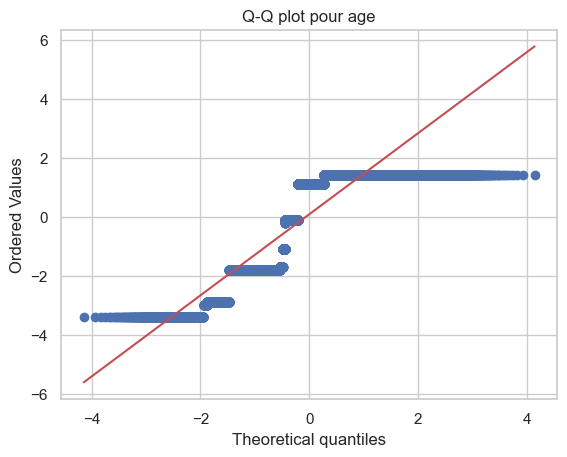

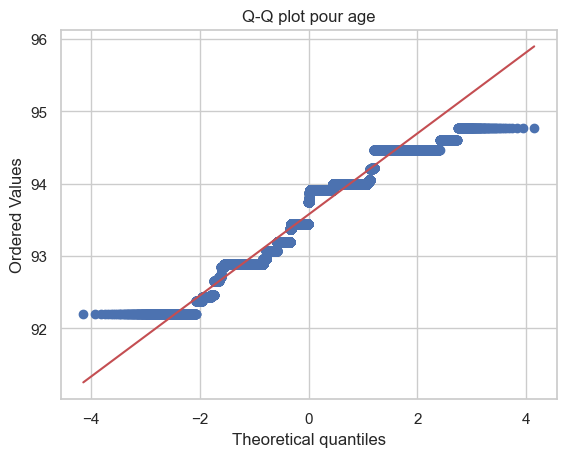

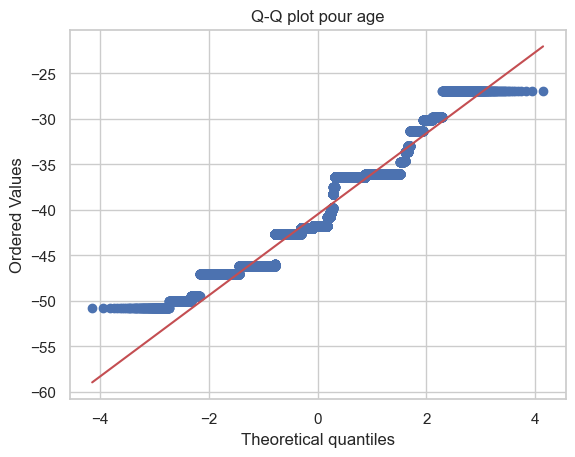

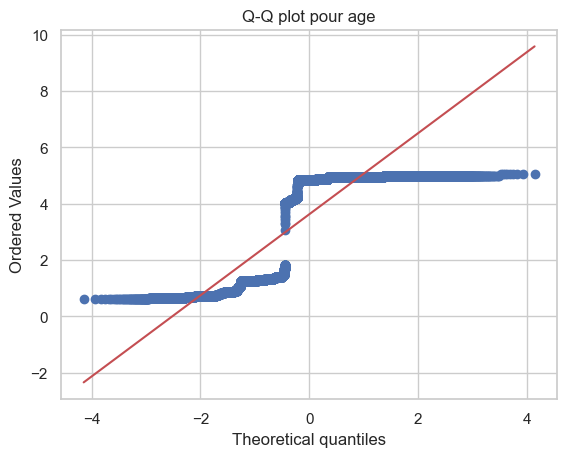

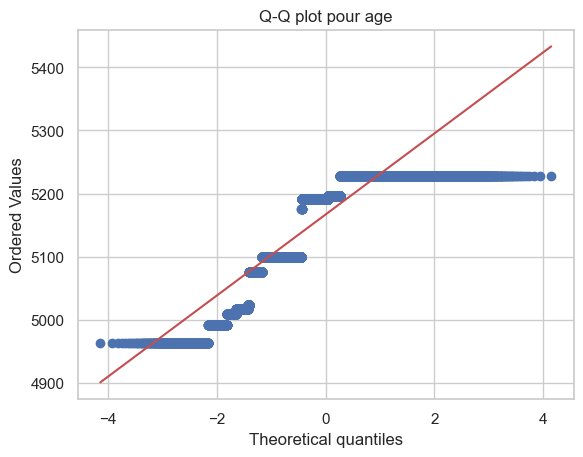

In [98]:
Q_Q_plot(bank_df, numerical_variables)